In [2]:
# Import required libraries
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
housing = fetch_california_housing()

In [6]:
X = housing.data

In [7]:
y = housing.target

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42
)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [15]:
print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)
print("\nModel Performance")
print("-----------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Training Set Shape : (16512, 8)
Testing Set Shape  : (4128, 8)

Model Performance
-----------------------------
Mean Absolute Error (MAE): 0.5332001304956565
Mean Squared Error (MSE): 0.5558915986952442
Root Mean Squared Error (RMSE): 0.7455813830127763
R² Score: 0.575787706032451


In [26]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

In [30]:
housing = fetch_california_housing()

In [32]:
X = housing.data
y = housing.target

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.20, random_state=42)

In [38]:
lr = LinearRegression()
svr = SVR(kernel='rbf')
dt = DecisionTreeRegressor(random_state=42)

In [40]:
lr.fit(X_train, y_train)
svr.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [41]:
lr_pred = lr.predict(X_test)
svr_pred = svr.predict(X_test)
dt_pred = dt.predict(X_test)

In [42]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = mse ** 0.5
    r2 = r2_score(actual, predicted)
    return [mae, mse, rmse, r2]

In [43]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regression"],
    "MAE": [
        evaluate_model(y_test, lr_pred)[0],
        evaluate_model(y_test, svr_pred)[0],
        evaluate_model(y_test, dt_pred)[0]
    ],
    "MSE": [
        evaluate_model(y_test, lr_pred)[1],
        evaluate_model(y_test, svr_pred)[1],
        evaluate_model(y_test, dt_pred)[1]
    ],
    "RMSE": [
        evaluate_model(y_test, lr_pred)[2],
        evaluate_model(y_test, svr_pred)[2],
        evaluate_model(y_test, dt_pred)[2]
    ],
    "R2 Score": [
        evaluate_model(y_test, lr_pred)[3],
        evaluate_model(y_test, svr_pred)[3],
        evaluate_model(y_test, dt_pred)[3]
    ]
})

In [44]:
print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)
print("\nModel Performance Comparison")
print(results)

Training Set Shape : (16512, 8)
Testing Set Shape  : (4128, 8)

Model Performance Comparison
                       Model       MAE       MSE      RMSE  R2 Score
0          Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Support Vector Regression  0.397763  0.355198  0.595985  0.728941
2   Decision Tree Regression  0.453784  0.494272  0.703045  0.622811


In [51]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
housing = fetch_california_housing()

In [56]:
X = housing.data
y = housing.target

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

In [59]:
model = LinearRegression()

In [60]:
model.fit(X_train, y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test)

In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [63]:
print("Regression Model Evaluation")
print("---------------------------")
print("Mean Absolute Error (MAE):", round(mae,4))
print("Mean Squared Error (MSE):", round(mse,4))
print("Root Mean Squared Error (RMSE):", round(rmse,4))
print("R2 Score:", round(r2,4))

Regression Model Evaluation
---------------------------
Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R2 Score: 0.5758


In [75]:
train_sizes, train_scores, test_scores = learning_curve(model,X_train,y_train,cv=5,
scoring="r2",train_sizes=np.linspace(0.1, 1.0, 10),random_state=42)

In [77]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

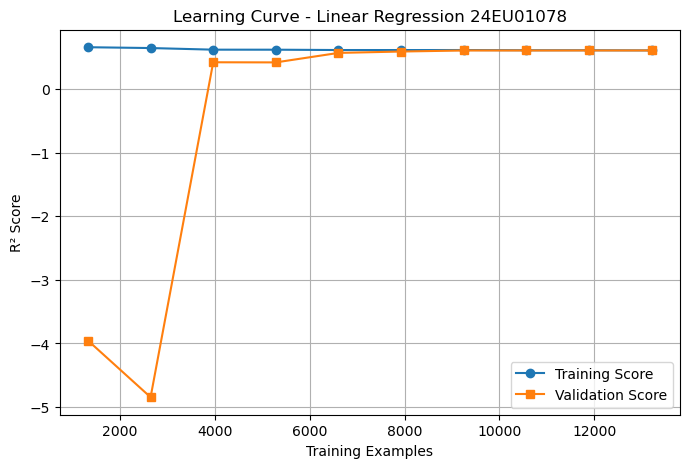

In [79]:
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Score')
plt.title("Learning Curve - Linear Regression 24EU01078")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()